In [1]:
include("CRD_STA.jl")
include("Fun.jl")
using NonlinearEigenproblems
using DelimitedFiles

In [11]:
N_cheb = 59
Mr = 0.3
gamma = 1.4
sigma = 0.72
Ro = 0.2
Co = 2 - Ro -Ro^2
Tw = 1
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,"cheb");
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;

In [5]:
be = 0.16

0.16

In [ ]:
data_total = [0 0 0 0 0 0]
for be = 0.1 : 0.002 : 0.3
    data_all = [0 0 0 0]
    data = [0 0 0 0]
    R = 190
    total = []
    Ma = Mr/R
    for ali = 0.18 : 0.002 : 0.4
        PinPoint= [0 0 0 0]
        al = 0.35 + ali *im
        alpha = []
        B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
        global C = eigen(B0,B1)
        global val = filter(x->-0.03<imag(x)<0.03&&abs(real(x))<0.05,C.values)

        for i = 1 : min(3,length(val))
            indi = []
            val_temp = val[i]
            for alr = 0.35 : 0.0015 : 0.5
                al = alr + ali *im
                vec = eigvector(val[i],C.values,C.vectors)
                B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
                val0,vec0 = RQI(B0,B1,val_temp,q0=vec)
                indi = [indi;val0]
                alpha = [alpha;al]
                val_temp = val0
                vec = vec0 
                end
            if i == 1
                total = indi
            else
                total = [total indi]
            end
        end
        for i = 1 : size(total,2)  

                d2 = diff1(real(total[:,i]),0.0015)
                
            for j = 1 : length(d2)-1

                if d2[j] * d2[j+1] < 0 && abs(d2[j+1])<0.005

                    PinPoint = [PinPoint;[R alpha[j,1] be total[j,i]]]

                end

            end
        end

        if PinPoint == [0 0 0 0]
            data_temp = [R be -1 -1]
        else
            data_temp = [R be PinPoint[findmax(imag(PinPoint[2:end,4]))[2] + 1,2] PinPoint[findmax(imag(PinPoint[2:end,4]))[2] + 1,4]]
        end
        data_all = [data_all;data_temp]
        writedlm("AS.dat",data_all[2:end,:])
        global data0 = data_all[2:end,:]
        if  length(axes(data0,1)) > 2 && imag(data0[end - 1,4])>imag(data0[end-2,4])&&imag(data0[end-1,4])>imag(data0[end,4])
            data = [data;data0[end-1:end-1,:]]
            writedlm("Dataall_$Tw _$Mr.dat",data0)
            break 
        elseif length(axes(data0,1)) > 2 && imag(data0[end - 2,4]) != -1 && imag(data0[end - 1,4]) == -1 && imag(data0[end,4]) == -1
            data = [data;data0[end-1:end-1,:]]
            writedlm("Dataall_$Tw _$Mr.dat",data[2:end,:])
            break 
        end
    end
    #section2
    global ali = imag(data[end,3])
    data_all = [0 0 0 0 0 0]
    data = [0 0 0 0]
    data1 = [0 0 0 0]
    for R = 160 : 0.5 : 220
        total = []
        Ma = Mr/R
        PinPoint= [0 0 0 0]
        al = 0.2 + ali *im
        alpha = []
        B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
        global C = eigen(B0,B1)
        global val = filter(x->-0.03<imag(x)<0.03&&abs(real(x))<0.1,C.values)

        for i = 1 : min(2,length(val))
            indi = []
            val_temp = val[i]
            for alr = 0.2 : 0.001 : 0.5
                al = alr + ali *im
                vec = eigvector(val[i],C.values,C.vectors)
                B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
                val0,vec0 = RQI(B0,B1,val_temp,q0=vec)
                indi = [indi;val0]
                alpha = [alpha;al]
                val_temp = val0
                vec = vec0 
            end
            if i == 1
                total = indi
            else
                total = [total indi]
            end
        end
        for i = 1 : size(total,2)
            d2 = diff1(real(total[:,i]),0.001)
            for j = 1 : length(d2)-1
                if d2[j] * d2[j+1] < 0 && abs(d2[j+1])<0.005
                    PinPoint = [PinPoint;[R alpha[j,1] be total[j,i]]]
                end
            end
        end
        if PinPoint == [0 0 0 0]
            data_temp = [R be -1 -1]
        else
            data_temp = [R be PinPoint[findmax(imag(PinPoint[2:end,4]))[2] + 1,2] PinPoint[findmax(imag(PinPoint[2:end,4]))[2] + 1,4]]
        end
        data1 = [data1;data_temp]
        data_all = [real(data1[:,1]) real(data1[:,2]) real(data1[:,3]) imag(data1[:,3]) real(data1[:,4]) imag(data1[:,4])]
        writedlm("AS1.dat",data_all[2:end,:])
        if data_all[end,6]>0 && data_all[end-1,6]<0
            data_total = [data_total;data_all[end:end,:]]
            writedlm("Dataall_$Tw _$Mr.dat",data_total)
            break
        end
    end
end    

In [ ]:
data_all1[2:,1]

34-element Vector{Float64}:
   0.0
 124.0
 124.5
 125.0
 125.5
 126.0
 126.5
 127.0
 127.5
 128.0
   ⋮
 136.0
 136.5
 137.0
 137.5
 138.0
 138.5
 139.0
 139.5
 140.0

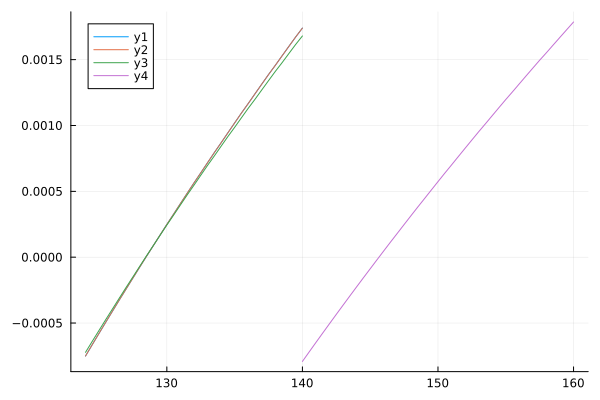

In [84]:
plot!(data_all[2:end,1],data_all[2:end,6])

In [459]:
data_all[end-1:end-1,:]

1×4 Matrix{ComplexF64}:
 124.5+0.0im  0.157+0.0im  0.395+0.19im  0.0213609-0.000674279im

In [408]:
PinPoint = [124 0.14 0.131+0.2im 0.3-0.3im;
            124 0.14 0.1+0.1im 0.25-0.1im;]
PinPoint[findmax(imag(PinPoint[:,4]))[2],3]
# PinPoint[2,3]
# findmax(imag(PinPoint[:,4]))[2]

0.1 + 0.1im

In [272]:
d2 = diff1(imag(total[:,1]),0.002)
@show PinPoint

1×2 Matrix{ComplexF64}:
 0.403+0.5im  0.0219664-0.000663728im

In [200]:
size(total,2)

5

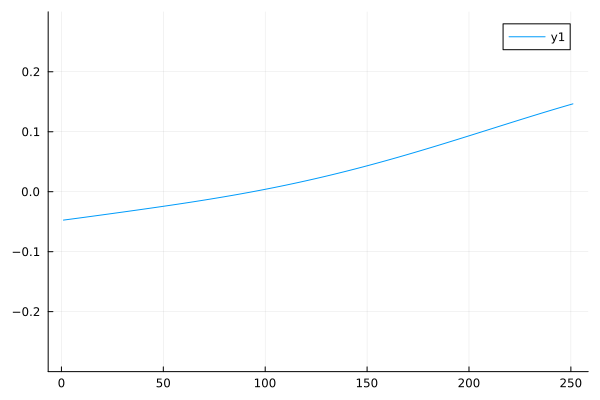

In [255]:
plot(d2,ylims = [-0.3,0.3])

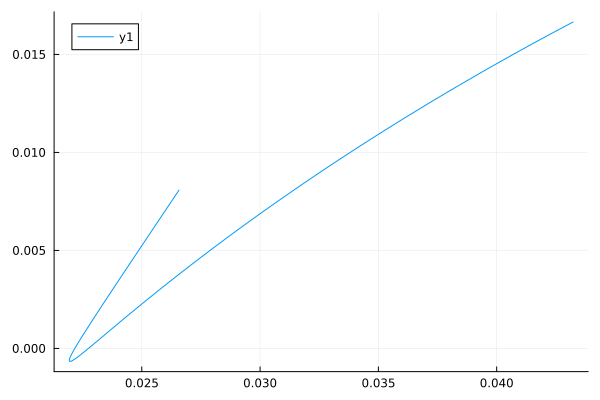

In [256]:
plot(real(total[:,1]),imag(total[:,1]))

In [3]:
data = readdlm("Dataall_0.8 _0.3.dat")[3:end,:]
data_positive = (data[data[:,1] .== 20,:])
# c = data[:,1] .= 30
# norm(c)

71×4 Matrix{Any}:
 20.0   0.2     0.185658  -0.0188462
 20.0   0.195   0.1807    -0.0188037
 20.0   0.19    0.175747  -0.018764
 20.0   0.185   0.170799  -0.0187272
 20.0   0.18    0.165865  -0.018999
 20.0   0.175   0.160931  -0.0189727
 20.0   0.17    0.156003  -0.0189482
 20.0   0.165   0.151081  -0.0189251
 20.0   0.16    0.146175  -0.0192313
 20.0   0.155   0.141271  -0.0192149
  ⋮                       
 20.0  -0.11   -0.224488  -0.00509223
 20.0  -0.115  -0.229016  -0.00537023
 20.0  -0.12   -0.233557  -0.005666
 20.0  -0.125  -1.0       -1.0
 20.0  -0.13   -1.0       -1.0
 20.0  -0.135  -1.0       -1.0
 20.0  -0.14   -0.150743  -0.010077
 20.0  -0.145  -0.155741  -0.010143
 20.0  -0.15   -0.160738  -0.0102118

In [31]:
include("Fun.jl")

extline (generic function with 1 method)

In [32]:
dat = extline(0,"Dataall_0.8 _0.3.dat")

28×4 Matrix{Any}:
 31.25  0.0  -0.106481  0.00834097
 31.0   0.0  -0.106757  0.00822172
 30.75  0.0  -0.107029  0.00809469
 30.5   0.0  -0.1073    0.00795907
 30.25  0.0  -0.107576  0.00764189
 30.0   0.0  -0.107844  0.00748552
 29.75  0.0  -0.108113  0.0073186
 29.5   0.0  -0.108391  0.00697405
 29.25  0.0  -0.108659  0.00678409
 29.0   0.0  -0.10893   0.00658138
  ⋮                     
 26.5   0.0  -0.111749  0.00309869
 26.25  0.0  -0.112033  0.00273327
 26.0   0.0  -0.112336  0.00224591
 25.75  0.0  -0.112623  0.00184572
 25.5   0.0  -0.115309  0.00153541
 25.25  0.0  -0.115791  0.00123314
 25.0   0.0  -0.116282  0.000926899
 24.75  0.0  -0.116782  0.000616499
 24.5   0.0  -0.117292  0.000301717

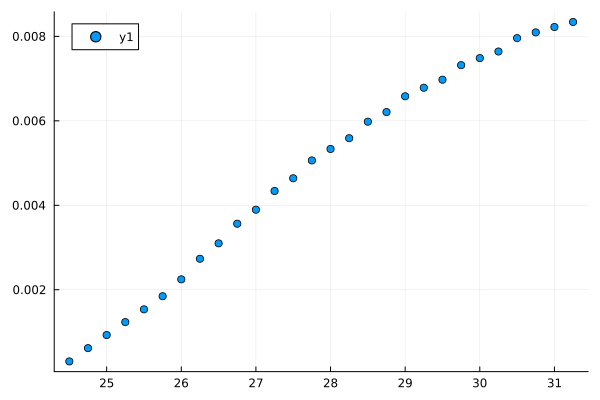

In [35]:
scatter(dat[:,1],dat[:,4])